<a href="https://colab.research.google.com/github/alexandre-sbrissia/challenge-Telecon-X-2/blob/main/TelleconX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd

url = "https://raw.githubusercontent.com/alexandre-sbrissia/challenge-Telecon-X-2/main/telecomx_tratado.csv"
df = pd.read_csv(url)

df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,tenure_group
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,0-1 ano
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,0-1 ano
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,0-1 ano
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,1-2 anos
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,0-1 ano


In [11]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   object 
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [12]:
df['Churn'] = df['Churn'].astype(str).str.strip()
df = df[df['Churn'].isin(['Yes','No'])].copy()

In [13]:
df['Churn'].value_counts(normalize=True).mul(100).round(2)

,proportion
Churn,
No,73.46
Yes,26.54


In [14]:
df['Churn_flag'] = df['Churn'].map({'Yes':1, 'No':0})

In [15]:
df[['Churn','Churn_flag']].head()

,Churn,Churn_flag
0,No,0
1,No,0
2,Yes,1
3,Yes,1
4,Yes,1


In [16]:
df_model = df.drop(columns=['customerID','Churn','tenure_group'])

In [17]:
df_model.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'Charges.Monthly', 'Charges.Total', 'Churn_flag'],
      dtype='object')

In [18]:
X = df_model.drop('Churn_flag', axis=1)
y = df_model['Churn_flag']

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [21]:
from sklearn.linear_model import LogisticRegression

model = Pipeline(steps=[
    ('prep', preprocess),
    ('classifier', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['tenure', 'Charges.Monthly', 'Charges.Total'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=2000))])

In [22]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

preds = model.predict(X_test)
proba = model.predict_proba(X_test)[:,1]

print(confusion_matrix(y_test, preds))
print(classification_report(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, proba))

[[933 361]
 [ 94 373]]
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1294
           1       0.51      0.80      0.62       467

    accuracy                           0.74      1761
   macro avg       0.71      0.76      0.71      1761
weighted avg       0.80      0.74      0.76      1761

ROC-AUC: 0.8391968863044392


In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ('prep', preprocess),
    ('classifier', RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight='balanced_subsample'
    ))
])

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:,1]

print("Random Forest")
print(confusion_matrix(y_test, rf_preds))
print(classification_report(y_test, rf_preds))
print("ROC-AUC:", roc_auc_score(y_test, rf_proba))

Random Forest
[[1157  137]
 [ 244  223]]
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1294
           1       0.62      0.48      0.54       467

    accuracy                           0.78      1761
   macro avg       0.72      0.69      0.70      1761
weighted avg       0.77      0.78      0.77      1761

ROC-AUC: 0.8186838281774885


In [24]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = Pipeline(steps=[
    ('prep', preprocess),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

gb_model.fit(X_train, y_train)

gb_preds = gb_model.predict(X_test)
gb_proba = gb_model.predict_proba(X_test)[:,1]

print("Gradient Boosting")
print(confusion_matrix(y_test, gb_preds))
print(classification_report(y_test, gb_preds))
print("ROC-AUC:", roc_auc_score(y_test, gb_proba))

Gradient Boosting
[[1151  143]
 [ 216  251]]
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1294
           1       0.64      0.54      0.58       467

    accuracy                           0.80      1761
   macro avg       0.74      0.71      0.72      1761
weighted avg       0.79      0.80      0.79      1761

ROC-AUC: 0.843544906652016


In [25]:
import numpy as np

threshold = 0.60  # teste 0.55, 0.60, 0.65

new_preds = (proba >= threshold).astype(int)

print(confusion_matrix(y_test, new_preds))
print(classification_report(y_test, new_preds))

[[1034  260]
 [ 131  336]]
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1294
           1       0.56      0.72      0.63       467

    accuracy                           0.78      1761
   macro avg       0.73      0.76      0.74      1761
weighted avg       0.80      0.78      0.79      1761



In [26]:
import numpy as np

feature_names = model.named_steps['prep'].get_feature_names_out()
coefficients = model.named_steps['classifier'].coef_[0]

importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

importance = importance.sort_values(by='Coefficient', ascending=False)

importance.head(15)

,Feature,Coefficient
2,num__Charges.Total,0.689633
37,cat__Contract_Month-to-month,0.652491
17,cat__InternetService_Fiber optic,0.534529
44,cat__PaymentMethod_Electronic check,0.274510
28,cat__TechSupport_No,0.195159
33,cat__StreamingTV_Yes,0.187729
36,cat__StreamingMovies_Yes,0.175942
19,cat__OnlineSecurity_No,0.147597
41,cat__PaperlessBilling_Yes,0.113479
15,cat__MultipleLines_Yes,0.086163


In [27]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'ROC_AUC': [
        roc_auc_score(y_test, proba),
        roc_auc_score(y_test, rf_proba),
        roc_auc_score(y_test, gb_proba)
    ]
})

results.sort_values(by='ROC_AUC', ascending=False)

,Model,ROC_AUC
2,Gradient Boosting,0.843545
0,Logistic Regression,0.839197
1,Random Forest,0.818684


In [28]:
threshold = 0.60

adjusted_preds = (proba >= threshold).astype(int)

print(confusion_matrix(y_test, adjusted_preds))
print(classification_report(y_test, adjusted_preds))

[[1034  260]
 [ 131  336]]
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1294
           1       0.56      0.72      0.63       467

    accuracy                           0.78      1761
   macro avg       0.73      0.76      0.74      1761
weighted avg       0.80      0.78      0.79      1761



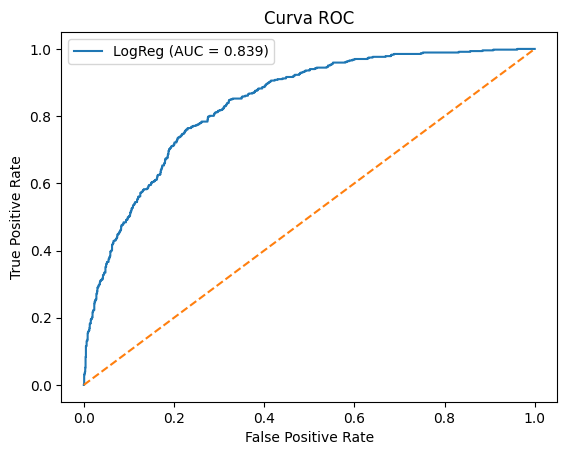

In [30]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, proba)

plt.figure()
plt.plot(fpr, tpr, label='LogReg (AUC = %.3f)' % roc_auc_score(y_test, proba))
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.show()

In [29]:
feature_names = model.named_steps['prep'].get_feature_names_out()
coefficients = model.named_steps['classifier'].coef_[0]

importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

importance = importance.sort_values(by='Coefficient', ascending=False)

importance.head(10)

,Feature,Coefficient
2,num__Charges.Total,0.689633
37,cat__Contract_Month-to-month,0.652491
17,cat__InternetService_Fiber optic,0.534529
44,cat__PaymentMethod_Electronic check,0.274510
28,cat__TechSupport_No,0.195159
33,cat__StreamingTV_Yes,0.187729
36,cat__StreamingMovies_Yes,0.175942
19,cat__OnlineSecurity_No,0.147597
41,cat__PaperlessBilling_Yes,0.113479
15,cat__MultipleLines_Yes,0.086163


In [31]:
df['churn_probability'] = model.predict_proba(X)[:,1]
df[['churn_probability']].head()

,churn_probability
0,0.297631
1,0.615407
2,0.850818
3,0.862520
4,0.795651
